In [138]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.linear_model import GammaRegressor
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

In [139]:
# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv('./Cleaned Data/cleaned_data.csv')

In [140]:
df = df[df['Total Time Spent'] > 0].reset_index(drop=True)


In [141]:
df

,Issue Type,Status,Priority,Summary,Original Time Estimated,Total Time Spent
0,Bug,Done,Blocker,"['When', 'integration', 'option', 'setup', 'su...",0,30
1,Bug,Done,Major,"['Getting', 'null', 'error', 'response', 'firs...",0,65
2,Story,Done,Critical,"['When', 'session', 'expires', 'I', 'taken', '...",60,60
3,Bug,Done,Major,"['All', 'connections', 'deleted', 'blank', 'co...",0,105
4,Task,Done,Major,"['Update', 'payment', 'config', 'mapping', 'un...",30,30
...,...,...,...,...,...,...
10271,Subtask,Done,Major,"['Add', 'form', 'creating', 'vendor', 'item']",120,60
10272,Subtask,Done,Major,"['Add', 'command', 'receiver', 'endpoint', 'cr...",120,60
10273,Subtask,In Progress,Major,"['Update', 'expense', 'form', 'show', 'list', ...",120,390
10274,Subtask,Done,Major,"['Add', 'form', 'editing', 'invoice']",120,40


In [142]:
# ----------------------------
# Feature definitions
# ----------------------------
text_features = 'Summary'
categorical_features = ['Issue Type', 'Priority']
target = 'Total Time Spent'


In [143]:
X = df[[text_features] + categorical_features]
y = df[df[target] > 0][target]  # Filter out rows with non-positive target values

In [144]:
# ----------------------------
# Step 1: Preprocess features (for clustering)
# ----------------------------
cluster_preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(
                max_features=300,
                min_df=3,
                ngram_range=(1, 2)
            ),
            'Summary'
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

X_features_for_clustering = cluster_preprocessor.fit_transform(X)

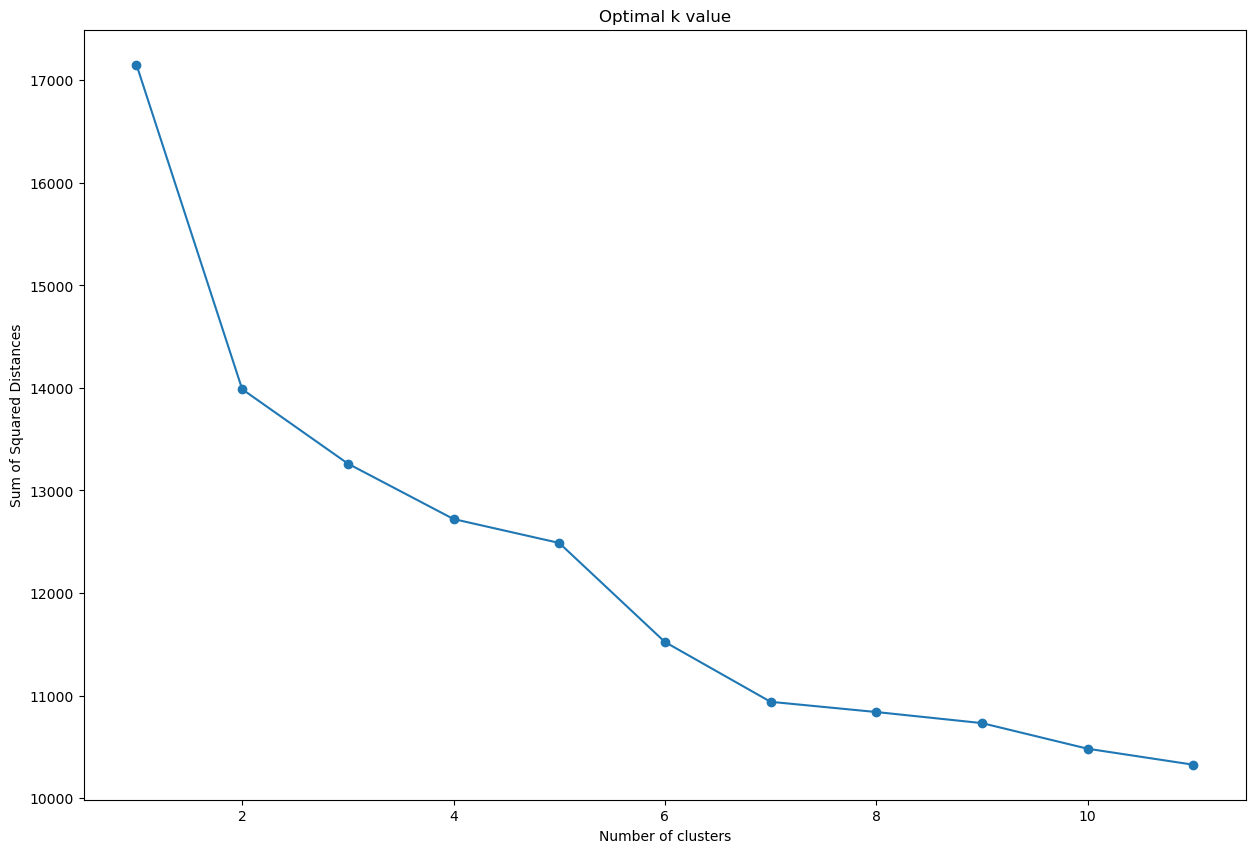

In [145]:
# use the elbow method to determine the optimal number of clusters
sum_of_squared_distances = []
for i in range(1, 12):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_features_for_clustering)
    sum_of_squared_distances.append(kmeans.inertia_)

plt.figure(figsize=(15, 10))
plt.plot(range(1, 12), sum_of_squared_distances, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Optimal k value')
plt.show()

In [146]:
# ----------------------------
# Step 2: Apply KMeans
# ----------------------------
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_features_for_clustering)

In [147]:
# ----------------------------
# Step 3: Build final model (cluster included)
# ----------------------------
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(
                max_features=300,
                min_df=3,
                ngram_range=(1, 2)
            ),
            'Summary'
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'cluster',
            OneHotEncoder(),
            ['cluster']
        )
    ]
)

In [148]:
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", GammaRegressor(max_iter=1000))
])

param_grid = {
    "model__alpha": np.logspace(-4, 2, 20)
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_features_for_clustering, y)

print("Best alpha:", grid.best_params_["model__alpha"])
print("Best CV score:", grid.best_score_)


Best alpha: 0.0008858667904100823
Best CV score: 0.3798173175850817


In [149]:
model = Pipeline(
    steps=[
        ('preprocessor', final_preprocessor),
        ('regressor', GammaRegressor(alpha=0.0008858667904100823))
    ]
)

In [150]:
# ----------------------------
# Train / test split
# ----------------------------
X_model = df[[text_features] + categorical_features + ['cluster']]
y_model = df[target]

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    random_state=42
)

In [152]:
y_train_log = np.log1p(y_train)  # Log-transform the target variable

In [153]:
# ----------------------------
# Train model
# ----------------------------
model.fit(X_train, y_train_log)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [154]:
# ----------------------------
# Evaluate
# ----------------------------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse log-transform the predictions
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 78.69


In [155]:
# ----------------------------
# Results dataframe
# ----------------------------
results = pd.DataFrame({
    'Summary': df.loc[X_test.index, 'Summary'],
    'Issue Type': df.loc[X_test.index, 'Issue Type'],
    'Priority': df.loc[X_test.index, 'Priority'],
    'Original Estimated Time': df.loc[X_test.index, 'Original Time Estimated'],
    'Actual Time Spent': y_test,
    'Predicted Time Spent': y_pred
})


In [156]:
results

,Summary,Issue Type,Priority,Original Estimated Time,Actual Time Spent,Predicted Time Spent
5601,"['Add', 'endpoint', 'upserting', 'disciplines']",Subtask,Major,60,60,98.439211
2108,"['Add', 'endpoint', 'saving', 'configuration']",Subtask,Major,120,205,127.513618
2516,"['I', 'get', 'analysis', 'AR', 'I', 'first', '...",Story,Major,0,75,68.415207
7318,['Feedback'],Subtask,Major,0,20,80.683110
33,"['What', 'caused', 'change', 'value', 'invento...",Subtask,Major,0,141,55.621513
...,...,...,...,...,...,...
4269,"['As', 'child', 'I', 'able', 'login', 'code']",Story,Major,0,120,151.713767
6762,"['update', 'PO', 'method', 'approve', 'POs']",Subtask,Major,30,60,74.301602
6965,"['Upgrade', 'version', 'opentelemetry', 'use']",Task,Critical,0,240,70.759586
4184,"['add', 'ela', 'writing', 'subject']",Subtask,Major,120,300,69.747028


In [157]:
results['Absolute Error Predicted'] = np.abs(
    results['Actual Time Spent'] - results['Predicted Time Spent']
)


In [158]:
# absolute error original
results['Absolute Error Original'] = np.abs(
    results['Actual Time Spent'] - results['Original Estimated Time']
)

In [159]:
results

,Summary,Issue Type,Priority,Original Estimated Time,Actual Time Spent,Predicted Time Spent,Absolute Error Predicted,Absolute Error Original
5601,"['Add', 'endpoint', 'upserting', 'disciplines']",Subtask,Major,60,60,98.439211,38.439211,0
2108,"['Add', 'endpoint', 'saving', 'configuration']",Subtask,Major,120,205,127.513618,77.486382,85
2516,"['I', 'get', 'analysis', 'AR', 'I', 'first', '...",Story,Major,0,75,68.415207,6.584793,75
7318,['Feedback'],Subtask,Major,0,20,80.683110,60.683110,20
33,"['What', 'caused', 'change', 'value', 'invento...",Subtask,Major,0,141,55.621513,85.378487,141
...,...,...,...,...,...,...,...,...
4269,"['As', 'child', 'I', 'able', 'login', 'code']",Story,Major,0,120,151.713767,31.713767,120
6762,"['update', 'PO', 'method', 'approve', 'POs']",Subtask,Major,30,60,74.301602,14.301602,30
6965,"['Upgrade', 'version', 'opentelemetry', 'use']",Task,Critical,0,240,70.759586,169.240414,240
4184,"['add', 'ela', 'writing', 'subject']",Subtask,Major,120,300,69.747028,230.252972,180


In [160]:
# mean absolute error original
mae_original = results['Absolute Error Original'].mean()
print(f"Mean Absolute Error (Original): {mae_original:.2f}")

Mean Absolute Error (Original): 90.41


In [161]:
# mean absolute error predicted
mae_predicted = results['Absolute Error Predicted'].mean()
print(f"Mean Absolute Error (Predicted): {mae_predicted:.2f}")

Mean Absolute Error (Predicted): 78.69


In [162]:
results.to_csv('prediction_results.csv', index=False)